<a href="https://colab.research.google.com/github/regitaaft/iris-eda-ml/blob/main/ML_tugas_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('ObesityDataSet.csv')
print(df.head())
print(df.columns)

   Gender   Age  Height  Weight family_history_with_overweight FAVC  FCVC  \
0  Female  21.0    1.62    64.0                            yes   no   2.0   
1  Female  21.0    1.52    56.0                            yes   no   3.0   
2    Male  23.0    1.80    77.0                            yes   no   2.0   
3    Male  27.0    1.80    87.0                             no   no   3.0   
4    Male  22.0    1.78    89.8                             no   no   2.0   

   NCP       CAEC SMOKE  CH2O  SCC  FAF  TUE        CALC  \
0  3.0  Sometimes    no   2.0   no  0.0  1.0          no   
1  3.0  Sometimes   yes   3.0  yes  3.0  0.0   Sometimes   
2  3.0  Sometimes    no   2.0   no  2.0  1.0  Frequently   
3  3.0  Sometimes    no   2.0   no  2.0  0.0  Frequently   
4  1.0  Sometimes    no   2.0   no  0.0  0.0   Sometimes   

                  MTRANS           NObeyesdad  
0  Public_Transportation        Normal_Weight  
1  Public_Transportation        Normal_Weight  
2  Public_Transportation        

Output tersebut menampilkan lima data pertama dari dataset yang digunakan dalam analisis. Data ini masih dalam bentuk mentah (raw data), di mana variabel kategori seperti jenis kelamin, kebiasaan makan, dan gaya hidup masih ditampilkan dalam bentuk teks, seperti Male, Female, yes, no, dan kategori lainnya.

Berdasarkan output tersebut, terlihat bahwa setiap baris merepresentasikan satu individu dengan berbagai karakteristik. Variabel Gender menunjukkan jenis kelamin, sedangkan Age, Height, dan Weight masing-masing menunjukkan umur, tinggi badan, dan berat badan. Selain itu, terdapat variabel family_history_with_overweight yang menunjukkan apakah individu memiliki riwayat keluarga dengan kelebihan berat badan, serta FAVC yang menunjukkan kebiasaan mengonsumsi makanan tinggi kalori.

Variabel lain seperti FCVC menunjukkan frekuensi konsumsi sayur, NCP menunjukkan jumlah makan utama per hari, dan CAEC menggambarkan kebiasaan makan di luar waktu makan utama (ngemil). Sementara itu, variabel gaya hidup seperti SMOKE, CH2O, SCC, FAF, dan TUE masing-masing menunjukkan kebiasaan merokok, konsumsi air, kontrol kalori, aktivitas fisik, serta waktu penggunaan perangkat teknologi.

Selain itu, variabel CALC menunjukkan frekuensi konsumsi alkohol, dan MTRANS menunjukkan jenis transportasi yang digunakan sehari-hari. Variabel terakhir yaitu NObeyesdad merupakan variabel target yang menunjukkan tingkat obesitas individu berdasarkan kategori tertentu, seperti Normal Weight, Overweight, dan lainnya.

In [4]:
df.isnull().sum()

,0
Gender,0
Age,0
Height,0
Weight,0
family_history_with_overweight,0
FAVC,0
FCVC,0
NCP,0
CAEC,0
SMOKE,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Gender                          2111 non-null   object 
 1   Age                             2111 non-null   float64
 2   Height                          2111 non-null   float64
 3   Weight                          2111 non-null   float64
 4   family_history_with_overweight  2111 non-null   object 
 5   FAVC                            2111 non-null   object 
 6   FCVC                            2111 non-null   float64
 7   NCP                             2111 non-null   float64
 8   CAEC                            2111 non-null   object 
 9   SMOKE                           2111 non-null   object 
 10  CH2O                            2111 non-null   float64
 11  SCC                             2111 non-null   object 
 12  FAF                             21

Berdasarkan output di atas, dataset terdiri dari 2111 data dengan 17 variabel yang terbagi menjadi data numerik dan kategori. Tidak terdapat missing value pada dataset.

In [6]:
df_encoded = pd.get_dummies(df, drop_first=True)
df_encoded.head()

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE,Gender_Male,family_history_with_overweight_yes,...,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking,NObeyesdad_Normal_Weight,NObeyesdad_Obesity_Type_I,NObeyesdad_Obesity_Type_II,NObeyesdad_Obesity_Type_III,NObeyesdad_Overweight_Level_I,NObeyesdad_Overweight_Level_II
0,21.0,1.62,64.0,2.0,3.0,2.0,0.0,1.0,False,True,...,False,False,True,False,True,False,False,False,False,False
1,21.0,1.52,56.0,3.0,3.0,3.0,3.0,0.0,False,True,...,False,False,True,False,True,False,False,False,False,False
2,23.0,1.80,77.0,2.0,3.0,2.0,2.0,1.0,True,True,...,False,False,True,False,True,False,False,False,False,False
3,27.0,1.80,87.0,3.0,3.0,2.0,2.0,0.0,True,False,...,False,False,False,True,False,False,False,False,True,False
4,22.0,1.78,89.8,2.0,1.0,2.0,0.0,0.0,True,False,...,False,False,True,False,False,False,False,False,False,True


Pada hasil preprocessing menggunakan one-hot encoding, nilai True menunjukkan bahwa individu termasuk dalam kategori tersebut, sedangkan False menunjukkan bahwa individu tidak termasuk dalam kategori tersebut.

Pada variabel Gender_Male, nilai True berarti responden berjenis kelamin laki-laki, sedangkan False berarti perempuan.

Penjelasan ini juga berlaku untuk variabel kategori lainnya, seperti:

**family_history_with_overweight_yes**

True → memiliki riwayat obesitas dalam keluarga

False → tidak memiliki riwayat

**FAVC_yes**

True → sering mengonsumsi makanan tinggi kalori

False → tidak

**SMOKE_yes**

True → merokok

False → tidak merokok

**MTRANS_Public_Transportation**

True → menggunakan transportasi umum

False → tidak

**NObeyesdad_Normal_Weight**

True → termasuk kategori berat badan normal

False → bukan kategori tersebut

Dengan adanya perubahan ini, seluruh variabel kategori telah berhasil dikonversi menjadi variabel numerik berbentuk biner (0 dan 1).

In [7]:
df.describe()

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000,2111.000000
mean,24.312600,1.701677,86.586058,2.419043,2.685628,2.008011,1.010298,0.657866
std,6.345968,0.093305,26.191172,0.533927,0.778039,0.612953,0.850592,0.608927
min,14.000000,1.450000,39.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,19.947192,1.630000,65.473343,2.000000,2.658738,1.584812,0.124505,0.000000
50%,22.777890,1.700499,83.000000,2.385502,3.000000,2.000000,1.000000,0.625350
75%,26.000000,1.768464,107.430682,3.000000,3.000000,2.477420,1.666678,1.000000
max,61.000000,1.980000,173.000000,3.000000,4.000000,3.000000,3.000000,2.000000


Berdasarkan statistik deskriptif, mayoritas responden berada pada usia muda dengan rata-rata sekitar 24 tahun. Rata-rata berat badan tergolong cukup tinggi, yaitu sekitar 86 kg, dengan variasi yang besar. Selain itu, tingkat aktivitas fisik relatif rendah, yang dapat menjadi salah satu faktor penyebab tingginya tingkat obesitas.

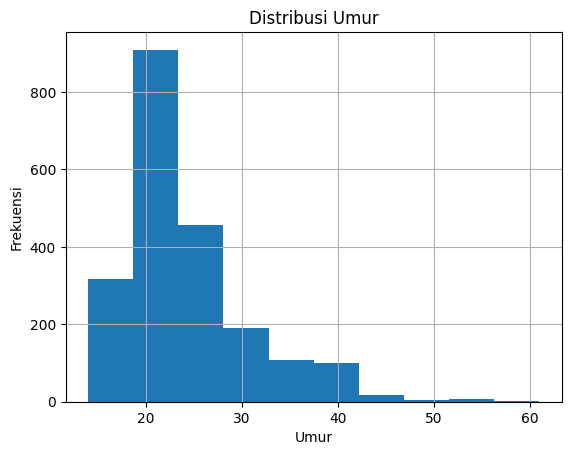

In [8]:

import matplotlib.pyplot as plt

df['Age'].hist()
plt.title('Distribusi Umur')
plt.xlabel('Umur')
plt.ylabel('Frekuensi')
plt.show()

Berdasarkan histogram, terlihat bahwa sebagian besar responden berada pada rentang usia sekitar 18 hingga 30 tahun. Puncak tertinggi ada di sekitar umur 20–25 tahun yang brarti menunjukkan bahwa analisis obesitas dalam dataset ini lebih merepresentasikan kondisi pada usia muda dibandingkan usia lanjut.

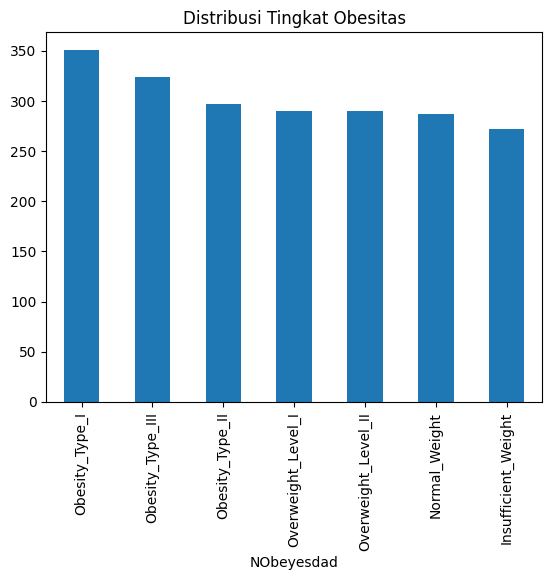

In [9]:
df['NObeyesdad'].value_counts().plot(kind='bar')
plt.title('Distribusi Tingkat Obesitas')
plt.show()

Variabel **NObeyesdad** dalam dataset ini menunjukkan tingkat obesitas individu yang diperoleh berdasarkan perhitungan Body Mass Index (BMI). BMI merupakan indikator yang digunakan untuk mengukur apakah seseorang memiliki berat badan yang ideal, kurang, atau berlebih, dengan mempertimbangkan tinggi dan berat badan. Nilai BMI dihitung menggunakan variabel Weight (berat badan) dan Height (tinggi badan), kemudian hasilnya digunakan untuk menentukan kategori tingkat obesitas.

Proses pembentukan variabel ini dimulai dari data tinggi dan berat badan yang dimiliki setiap individu. Berdasarkan kedua variabel tersebut, dihitung nilai BMI, yang kemudian diklasifikasikan ke dalam beberapa kategori, yaitu Insufficient Weight, Normal Weight, Overweight Level I, Overweight Level II, serta Obesity Type I, II, dan III. Kategori-kategori inilah yang selanjutnya direpresentasikan dalam variabel NObeyesdad sebagai variabel target dalam analisis.

Berdasarkan output visualisasi distribusi tingkat obesitas yang telah ditampilkan, terlihat bahwa jumlah individu pada setiap kategori relatif seimbang, dengan kategori Obesity Type I memiliki jumlah paling banyak. Hal ini menunjukkan bahwa sebagian besar individu dalam dataset berada pada tahap awal obesitas. Distribusi tersebut merupakan hasil dari pengelompokan nilai BMI yang berasal dari kombinasi berat badan dan tinggi badan, sehingga grafik yang dihasilkan tidak berdiri sendiri, melainkan merupakan hasil olahan dari variabel dasar yang ada dalam dataset.

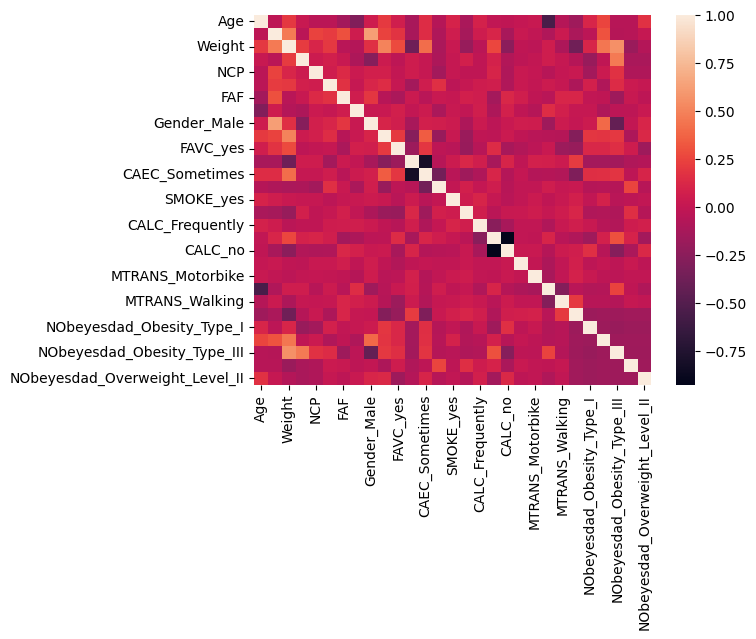

In [10]:
import seaborn as sns

sns.heatmap(df_encoded.corr())
plt.show()

Visualisasi heatmap korelasi digunakan untuk melihat hubungan antar variabel dalam dataset, baik antar variabel numerik maupun hasil encoding dari variabel kategori. Pada grafik tersebut, warna menunjukkan kekuatan hubungan antar variabel, di mana warna yang semakin terang mengindikasikan korelasi yang semakin kuat (mendekati 1), sedangkan warna yang lebih gelap menunjukkan korelasi yang lemah atau bahkan negatif (mendekati -1). Nilai korelasi sendiri berada pada rentang -1 hingga 1, di mana nilai mendekati 1 menunjukkan hubungan positif yang kuat, dan mendekati -1 menunjukkan hubungan negatif yang kuat.

Berdasarkan heatmap yang ditampilkan, terlihat bahwa beberapa variabel memiliki hubungan yang cukup kuat, terutama antara variabel yang berkaitan dengan kondisi fisik seperti Weight (berat badan) dengan kategori tingkat obesitas (NObeyesdad). Hal ini menunjukkan bahwa berat badan memiliki pengaruh yang signifikan terhadap tingkat obesitas seseorang. Selain itu, terdapat juga hubungan antara beberapa variabel gaya hidup seperti aktivitas fisik (FAF) dan kebiasaan makan, meskipun korelasinya cenderung lebih lemah dibandingkan dengan variabel fisik.

Di sisi lain, sebagian besar variabel lainnya menunjukkan korelasi yang relatif rendah, yang berarti tidak memiliki hubungan linear yang kuat satu sama lain. Hal ini mengindikasikan bahwa faktor-faktor yang mempengaruhi obesitas tidak hanya berasal dari satu variabel saja, melainkan kombinasi dari berbagai faktor seperti kebiasaan makan, aktivitas fisik, dan kondisi individu. Selain itu, terlihat bahwa variabel hasil encoding dari kategori obesitas memiliki pola tertentu, di mana setiap kategori memiliki hubungan yang saling berlawanan karena berasal dari satu variabel yang sama.

Dengan demikian, heatmap korelasi ini memberikan gambaran bahwa variabel berat badan merupakan faktor yang paling dominan dalam menentukan tingkat obesitas, sementara variabel lainnya berperan sebagai faktor pendukung.

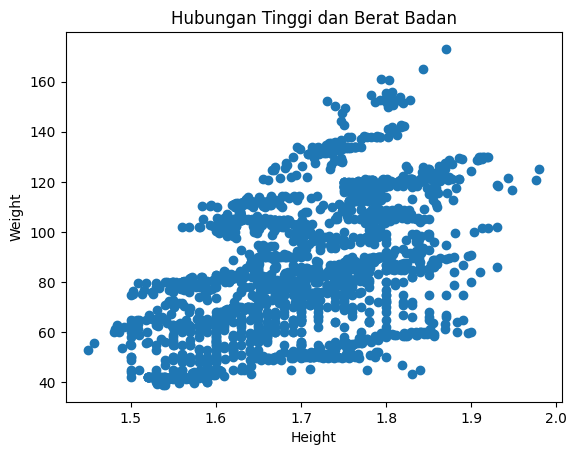

In [11]:
plt.scatter(df['Height'], df['Weight'])
plt.xlabel('Height')
plt.ylabel('Weight')
plt.title('Hubungan Tinggi dan Berat Badan')
plt.show()

Visualisasi scatter plot digunakan untuk melihat hubungan antara dua variabel numerik, yaitu Height (tinggi badan) dan Weight (berat badan). Pada grafik tersebut, setiap titik merepresentasikan satu individu, dengan posisi horizontal menunjukkan tinggi badan dan posisi vertikal menunjukkan berat badan. Dengan menggunakan scatter plot, pola hubungan antara kedua variabel dapat diamati secara langsung.

Berdasarkan grafik yang ditampilkan, terlihat adanya kecenderungan hubungan positif antara tinggi badan dan berat badan. Hal ini ditunjukkan dengan pola titik yang cenderung naik ke arah kanan atas, yang berarti bahwa semakin tinggi seseorang, maka berat badannya juga cenderung meningkat. Meskipun demikian, sebaran titik tidak membentuk garis lurus yang sempurna, sehingga hubungan antara kedua variabel tidak sepenuhnya kuat atau linear.

Selain itu, terlihat bahwa terdapat variasi berat badan yang cukup besar pada tinggi badan tertentu. Pada scater plot di atas pada tinggi sekitar 1.7 meter, berat badan individu dapat bervariasi dari sekitar 50 kg hingga lebih dari 120 kg. Hal ini menunjukkan bahwa berat badan tidak hanya dipengaruhi oleh tinggi badan saja, tetapi juga oleh faktor lain seperti pola makan, aktivitas fisik, dan gaya hidup. Maka dapat disimpulkan bahwa terdapat hubungan positif antara tinggi badan dan berat badan, namun hubungan tersebut tidak terlalu kuat karena dipengaruhi oleh berbagai faktor lain.

**KESIMPULAN**

Berdasarkan hasil analisis dan visualisasi data yang telah dilakukan, dapat disimpulkan bahwa dataset obesitas ini memiliki karakteristik yang cukup lengkap dalam menggambarkan kondisi fisik dan gaya hidup individu. Dari hasil preprocessing, seluruh variabel kategori telah berhasil diubah menjadi bentuk numerik melalui proses encoding, sehingga data siap digunakan untuk analisis lebih lanjut tanpa kendala missing value.

Hasil analisis statistik deskriptif menunjukkan bahwa mayoritas responden berada pada usia muda dengan rata-rata sekitar 24 tahun, serta memiliki variasi berat badan yang cukup besar. Hal ini mengindikasikan adanya perbedaan kondisi fisik yang signifikan antar individu dalam dataset. Selain itu, tingkat aktivitas fisik yang relatif rendah juga menjadi salah satu indikasi yang dapat berkontribusi terhadap peningkatan risiko obesitas.

Berdasarkan visualisasi distribusi, terlihat bahwa data umur didominasi oleh kelompok usia produktif, sedangkan distribusi tingkat obesitas menunjukkan bahwa kategori obesitas, khususnya Obesity Type I, memiliki jumlah yang cukup dominan meskipun secara keseluruhan distribusi data tergolong seimbang. Hal ini menunjukkan bahwa masalah obesitas cukup banyak terjadi dalam populasi yang diamati.

Dari analisis hubungan antar variabel, diketahui bahwa berat badan memiliki hubungan yang cukup kuat dengan tingkat obesitas, yang memang secara konsep berasal dari perhitungan Body Mass Index (BMI) berdasarkan berat dan tinggi badan. Sementara itu, hasil scatter plot menunjukkan adanya hubungan positif antara tinggi badan dan berat badan, meskipun tidak terlalu kuat karena dipengaruhi oleh faktor lain seperti pola makan dan aktivitas fisik.

Secara keseluruhan, dapat disimpulkan bahwa tingkat obesitas tidak hanya dipengaruhi oleh satu faktor saja, melainkan merupakan hasil interaksi dari berbagai faktor seperti kondisi fisik, kebiasaan makan, aktivitas fisik, serta gaya hidup individu. Oleh karena itu, analisis ini memberikan gambaran bahwa pendekatan yang komprehensif sangat diperlukan dalam memahami dan mengatasi permasalahan obesitas.